# Comparación downstream común

Este notebook compara el efecto de añadir trayectorias sintéticas del **block bootstrap condicionado, CVAE, Normalizing Flow y GAN condicional** al entrenamiento de una única arquitectura financiera.

> **Ejecución reproducible:** el notebook regenera por defecto el experimento completo antes de cargar las tablas. Esto evita reutilizar silenciosamente resultados de una versión anterior del bootstrap.

## Protocolo congelado

- Entrada: 14 variables que describen el estado de mercado previo.
- Objetivo: máximo drawdown a 30 días de una cartera 60 % BTC / 40 % ETH.
- Arquitectura: la misma MLP `64 → 32 → 1`, con la misma inicialización, optimizador y escalado.
- Mezclas: `0`, `+25`, `+50` y `+100 %` de sintéticos respecto al tamaño del train real.
- Validación y test: siempre reales.
- Condiciones sintéticas: solo estados pertenecientes a train. Los cuatro métodos, incluido el bootstrap, reciben la misma condición normalizada.

La ejecución completa se regenera desde la raíz con:

```bash
uv run --frozen python scripts/run_common_downstream_comparison.py --device cpu
```

In [1]:
from pathlib import Path
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUT = ROOT / 'outputs/downstream_common'
RUN_EXPERIMENT = True  # Entrena de nuevo todas las mezclas antes de mostrar resultados.
if RUN_EXPERIMENT:
    subprocess.run(
        ['uv', 'run', '--frozen', 'python', str(ROOT / 'scripts/run_common_downstream_comparison.py'), '--device', 'cpu'],
        cwd=ROOT, check=True,
    )
comparison = pd.read_csv(OUTPUT / 'comparison.csv')
MODEL_ORDER = ['block_bootstrap', 'cvae', 'normalizing_flow', 'conditional_gan']
RATIO_ORDER = [0.0, 0.25, 0.50, 1.0]

assert len(comparison) == 16
assert set(comparison['model']) == set(MODEL_ORDER)
assert comparison.groupby('model').size().eq(4).all()
comparison[['model', 'dataset', 'real_train', 'synthetic_train', 'total_train']]


MODELO: block_bootstrap
block_bootstrap: generadas  256/4710 trayectorias
block_bootstrap: generadas  512/4710 trayectorias
block_bootstrap: generadas  768/4710 trayectorias
block_bootstrap: generadas 1024/4710 trayectorias
block_bootstrap: generadas 1280/4710 trayectorias
block_bootstrap: generadas 1536/4710 trayectorias
block_bootstrap: generadas 1792/4710 trayectorias
block_bootstrap: generadas 2048/4710 trayectorias
block_bootstrap: generadas 2304/4710 trayectorias
block_bootstrap: generadas 2560/4710 trayectorias
block_bootstrap: generadas 2816/4710 trayectorias
block_bootstrap: generadas 3072/4710 trayectorias
block_bootstrap: generadas 3328/4710 trayectorias
block_bootstrap: generadas 3584/4710 trayectorias
block_bootstrap: generadas 3840/4710 trayectorias
block_bootstrap: generadas 4096/4710 trayectorias
block_bootstrap: generadas 4352/4710 trayectorias
block_bootstrap: generadas 4608/4710 trayectorias
block_bootstrap: generadas 4710/4710 trayectorias

block_bootstrap/real_onl

,model,dataset,real_train,synthetic_train,total_train
0,block_bootstrap,real_only,4710,0,4710
1,block_bootstrap,real_plus_25pct,4710,1178,5888
2,block_bootstrap,real_plus_50pct,4710,2355,7065
3,block_bootstrap,real_plus_100pct,4710,4710,9420
4,cvae,real_only,4710,0,4710
5,cvae,real_plus_25pct,4710,1178,5888
6,cvae,real_plus_50pct,4710,2355,7065
7,cvae,real_plus_100pct,4710,4710,9420
8,normalizing_flow,real_only,4710,0,4710
9,normalizing_flow,real_plus_25pct,4710,1178,5888


## Resultados sobre test real

Los porcentajes siguientes se expresan en puntos porcentuales de drawdown. `R² < 0` significa que la arquitectura sigue rindiendo peor que predecir la media del test; una reducción de MAE debe interpretarse como una mejora relativa, no como un predictor ya satisfactorio.

In [2]:
display_table = comparison[[
    'model', 'dataset', 'validation_mae', 'test_mae', 'test_rmse',
    'test_r2', 'test_tail_mae_worst_10pct',
]].copy()
for column in ['validation_mae', 'test_mae', 'test_rmse', 'test_tail_mae_worst_10pct']:
    display_table[column] *= 100
display_table.style.format({
    'validation_mae': '{:.3f} %',
    'test_mae': '{:.3f} %',
    'test_rmse': '{:.3f} %',
    'test_r2': '{:.3f}',
    'test_tail_mae_worst_10pct': '{:.3f} %',
})

,model,dataset,validation_mae,test_mae,test_rmse,test_r2,test_tail_mae_worst_10pct
0,block_bootstrap,real_only,4.752 %,7.955 %,10.071 %,-0.467,21.927 %
1,block_bootstrap,real_plus_25pct,4.599 %,8.468 %,10.828 %,-0.696,23.277 %
2,block_bootstrap,real_plus_50pct,4.858 %,8.496 %,10.580 %,-0.620,22.057 %
3,block_bootstrap,real_plus_100pct,4.851 %,8.636 %,10.798 %,-0.687,22.304 %
4,cvae,real_only,4.752 %,7.955 %,10.071 %,-0.467,21.927 %
5,cvae,real_plus_25pct,4.703 %,7.770 %,10.024 %,-0.454,22.273 %
6,cvae,real_plus_50pct,4.736 %,7.753 %,9.970 %,-0.438,22.056 %
7,cvae,real_plus_100pct,4.716 %,7.544 %,9.802 %,-0.390,21.888 %
8,normalizing_flow,real_only,4.752 %,7.955 %,10.071 %,-0.467,21.927 %
9,normalizing_flow,real_plus_25pct,4.888 %,7.898 %,9.985 %,-0.443,21.689 %


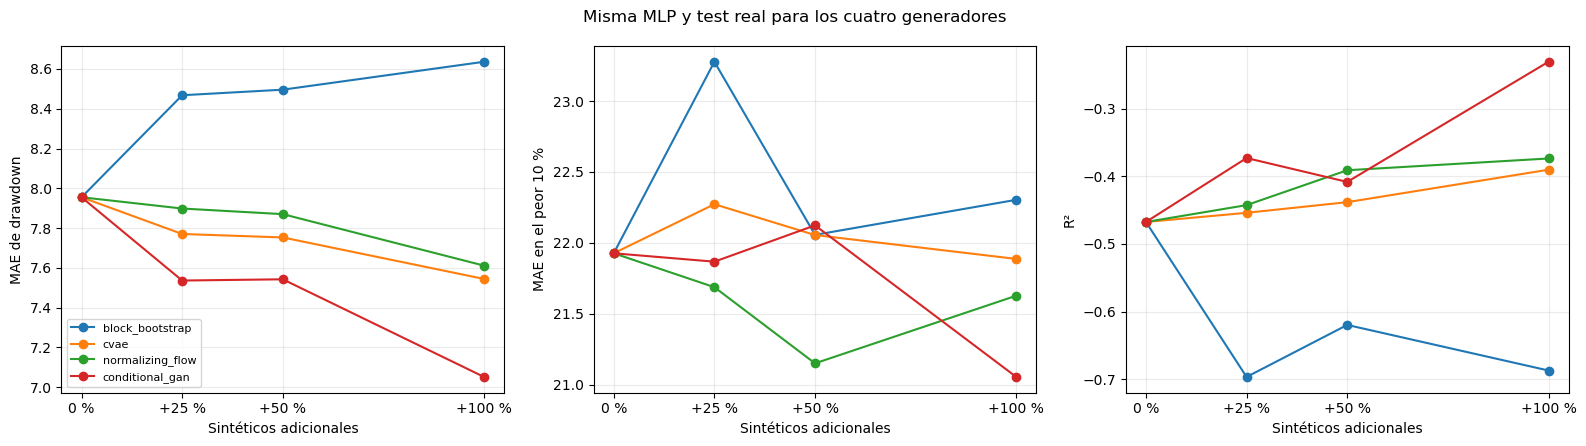

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = [
    ('test_mae', 'MAE de drawdown'),
    ('test_tail_mae_worst_10pct', 'MAE en el peor 10 %'),
    ('test_r2', 'R²'),
]
for axis, (metric, ylabel) in zip(axes, metrics):
    for model_name in MODEL_ORDER:
        rows = comparison.loc[comparison['model'].eq(model_name)].sort_values('additional_synthetic_ratio')
        values = rows[metric] * (100 if metric != 'test_r2' else 1)
        axis.plot(RATIO_ORDER, values, marker='o', label=model_name)
    axis.set_xticks(RATIO_ORDER, ['0 %', '+25 %', '+50 %', '+100 %'])
    axis.set_xlabel('Sintéticos adicionales')
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)
axes[0].legend(fontsize=8)
fig.suptitle('Misma MLP y test real para los cuatro generadores')
fig.tight_layout()
plt.show()

## Curvas de entrenamiento de CVAE y bootstrap

Las curvas permiten verificar la convergencia y el checkpoint elegido por validación para cada mezcla nueva.

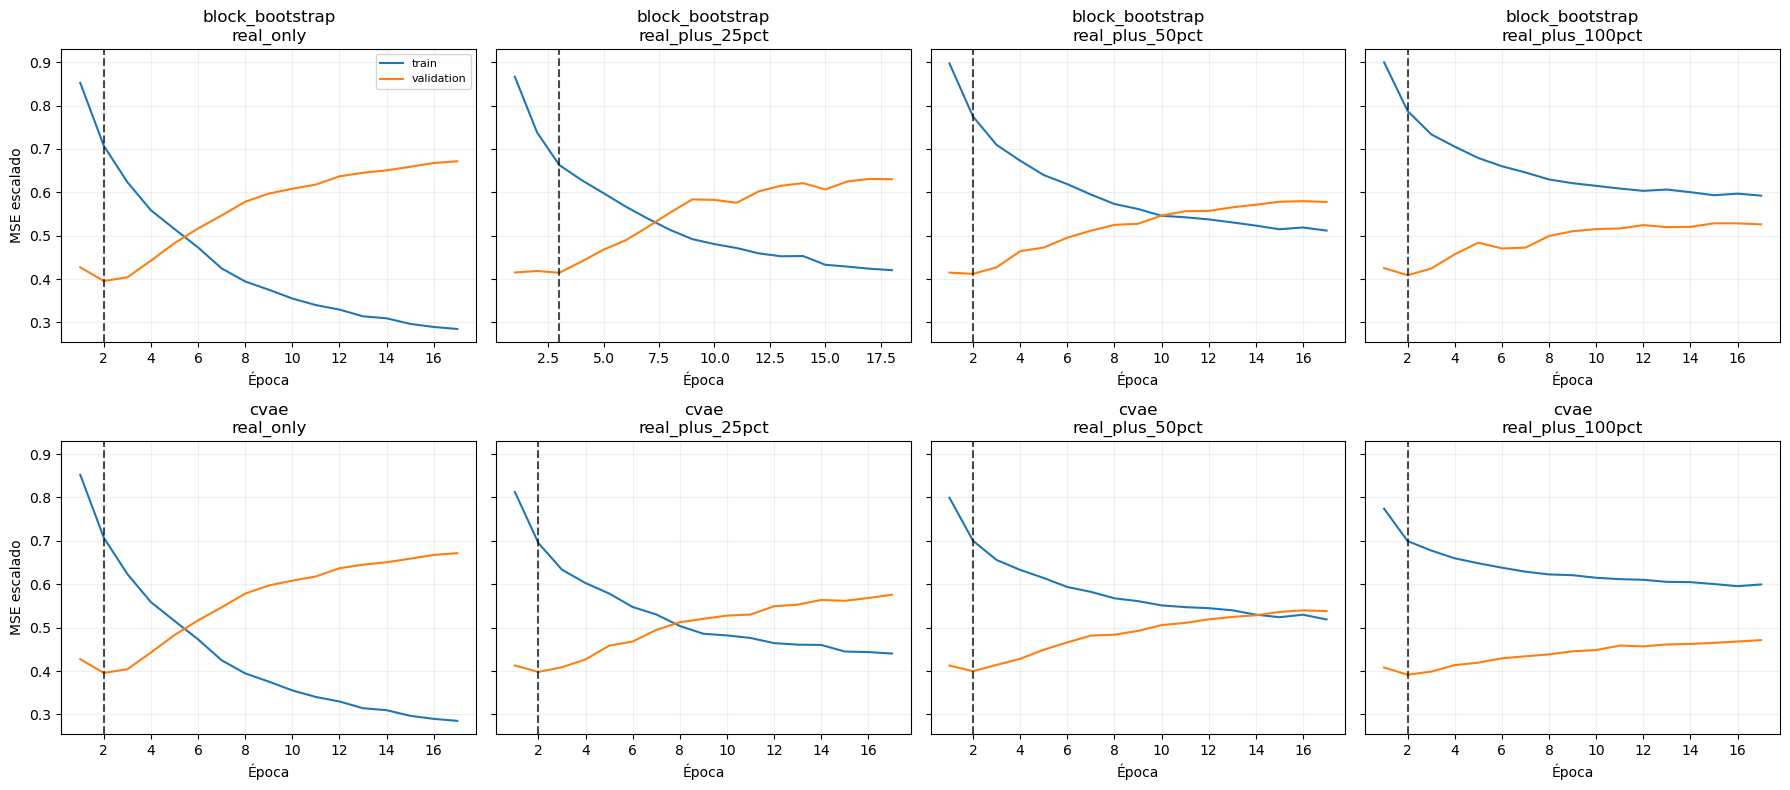

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
for row_index, model_name in enumerate(['block_bootstrap', 'cvae']):
    model_rows = comparison.loc[comparison['model'].eq(model_name)].sort_values('additional_synthetic_ratio')
    for axis, result in zip(axes[row_index], model_rows.itertuples(index=False)):
        history = pd.read_csv(OUTPUT / model_name / f'history_{result.dataset}.csv')
        axis.plot(history['epoch'], history['train_mse_scaled'], label='train')
        axis.plot(history['epoch'], history['validation_mse_scaled'], label='validation')
        axis.axvline(result.best_epoch, linestyle='--', color='black', alpha=0.7)
        axis.set_title(f'{model_name}\n{result.dataset}')
        axis.set_xlabel('Época')
        axis.grid(alpha=0.2)
axes[0, 0].set_ylabel('MSE escalado')
axes[1, 0].set_ylabel('MSE escalado')
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Selección sin utilizar test

Para no elegir retrospectivamente la proporción que mejor funciona en test, seleccionamos dentro de cada generador la mezcla con menor MAE de validación y mostramos después su resultado en test.

In [5]:
selected = (
    comparison.sort_values(['model', 'validation_mae'])
    .groupby('model', sort=False, as_index=False)
    .first()[['model', 'dataset', 'validation_mae', 'test_mae', 'test_r2', 'test_tail_mae_worst_10pct']]
)
selected[['validation_mae', 'test_mae', 'test_tail_mae_worst_10pct']] *= 100
selected.style.format({
    'validation_mae': '{:.3f} %',
    'test_mae': '{:.3f} %',
    'test_r2': '{:.3f}',
    'test_tail_mae_worst_10pct': '{:.3f} %',
})

,model,dataset,validation_mae,test_mae,test_r2,test_tail_mae_worst_10pct
0,block_bootstrap,real_plus_25pct,4.599 %,8.468 %,-0.696,23.277 %
1,conditional_gan,real_only,4.752 %,7.955 %,-0.467,21.927 %
2,cvae,real_plus_25pct,4.703 %,7.770 %,-0.454,22.273 %
3,normalizing_flow,real_only,4.752 %,7.955 %,-0.467,21.927 %


## Conclusión

El experimento ya utiliza el bootstrap condicionado con el mismo conjunto de condiciones de train que los modelos neuronales. La selección basada solo en validación elige `real_plus_25pct` para bootstrap y CVAE, y `real_only` para flow y GAN.

En el bootstrap, la mezcla seleccionada reduce el MAE de validación de 4,752 a 4,599 puntos porcentuales, pero no generaliza: en test el MAE aumenta de 7,955 a 8,468, el MAE de la peor decila pasa de 21,927 a 23,277 y el `R²` cae de −0,467 a −0,696. Además, ninguna proporción sintética del bootstrap supera descriptivamente a `real_only` en test.

El 25 % de CVAE sí transfiere una mejora modesta del MAE global a test —de 7,955 a 7,770—, aunque empeora ligeramente el error de la peor decila. Las mejoras máximas de test con 100 % de CVAE, flow o GAN son descriptivas porque esas mezclas no fueron seleccionadas por validación. Finalmente, todos los `R²` de las mezclas seleccionadas siguen siendo negativos: las mejoras relativas de MAE no bastan para considerar sólido el predictor financiero.